## Exploratory Data Analysis (EDA) on Hospital Dataset

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

### 2. Load Dataset

In [2]:
hdf =pd.read_csv("hospitals.csv")
adf = pd.read_csv("hos_admissions.csv")
pdf = pd.read_csv("hos_patients.csv")
ddf = pd.read_csv("hos_doctors.csv")
tdf =pd.read_csv("hos_treatments.csv")

### 3. Dataset Information

In [86]:
hdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hospital_ID    8 non-null      str    
 1   Hospital_Name  8 non-null      str    
 2   City           8 non-null      str    
 3   Beds           8 non-null      int64  
 4   Rating         8 non-null      float64
dtypes: float64(1), int64(1), str(3)
memory usage: 452.0 bytes


In [87]:
adf.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Admission_ID     5000 non-null   str           
 1   Patient_ID       5000 non-null   str           
 2   Admission_Date   5000 non-null   datetime64[us]
 3   Discharge_Date   5000 non-null   datetime64[us]
 4   Department       5000 non-null   str           
 5   Hospital_ID      5000 non-null   str           
 6   Bill             5000 non-null   int64         
 7   Admission_Month  5000 non-null   int32         
dtypes: datetime64[us](2), int32(1), int64(1), str(4)
memory usage: 293.1 KB


In [88]:
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Patient_ID   5000 non-null   str     
 1   Name         5000 non-null   str     
 2   Gender       5000 non-null   str     
 3   Age          5000 non-null   int64   
 4   Blood_Group  5000 non-null   str     
 5   City         5000 non-null   str     
 6   Weight       5000 non-null   int64   
 7   Height       5000 non-null   int64   
 8   Diabetes     5000 non-null   str     
 9   Smoking      5000 non-null   str     
 10  Age_Group    5000 non-null   category
 11  BMI          5000 non-null   float64 
dtypes: category(1), float64(1), int64(3), str(7)
memory usage: 434.9 KB


In [89]:
ddf.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Doctor_ID   80 non-null     str  
 1   Name        80 non-null     str  
 2   Department  80 non-null     str  
 3   Experience  80 non-null     int64
 4   Salary      80 non-null     int64
dtypes: int64(2), str(3)
memory usage: 3.3 KB


In [95]:
tdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Treatment_ID   5000 non-null   str   
 1   Patient_ID     5000 non-null   str   
 2   Disease        5000 non-null   str   
 3   Medicine       5000 non-null   str   
 4   Recovery_Days  5000 non-null   object
dtypes: object(1), str(4)
memory usage: 195.4+ KB


### 4.Data Cleaning

In [8]:
# Hospital Dataset

In [9]:
hdf.isnull().sum()

Hospital_ID      0
Hospital_Name    0
City             0
Beds             0
Rating           1
dtype: int64

In [105]:
hdf["Rating"].min()

np.float64(3.9)

In [104]:
hdf["Rating"].max()

np.float64(4.8)

In [10]:
hdf["Rating"] = hdf["Rating"].fillna(hdf["Rating"].mean())

In [11]:
# Admission Dataset

In [12]:
adf.duplicated().sum()

np.int64(0)

In [13]:
adf.isnull().sum()

Admission_ID       0
Patient_ID         0
Admission_Date     0
Discharge_Date    60
Department         0
Hospital_ID        0
Bill              63
dtype: int64

In [14]:
adf["Admission_Date"] = pd.to_datetime(adf["Admission_Date"], format = "mixed")

In [15]:
adf["Discharge_Date"] = pd.to_datetime(adf["Discharge_Date"], format = "mixed")

In [16]:
kk = pd.merge(adf,tdf, on = "Patient_ID")

In [17]:
kk.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Admission_ID    5000 non-null   str           
 1   Patient_ID      5000 non-null   str           
 2   Admission_Date  5000 non-null   datetime64[us]
 3   Discharge_Date  4940 non-null   datetime64[us]
 4   Department      5000 non-null   str           
 5   Hospital_ID     5000 non-null   str           
 6   Bill            4937 non-null   float64       
 7   Treatment_ID    5000 non-null   str           
 8   Disease         5000 non-null   str           
 9   Medicine        5000 non-null   str           
 10  Recovery_Days   4951 non-null   float64       
dtypes: datetime64[us](2), float64(2), str(7)
memory usage: 429.8 KB


In [18]:
kk["Recovery_Days"] = kk["Recovery_Days"].fillna(0).astype(int)

In [118]:
kk["Recovery_Days"] = kk["Recovery_Days"].abs()

In [119]:
kk["Discharge_Date"] = kk["Discharge_Date"].fillna(pd.to_datetime(kk["Admission_Date"]) + pd.to_timedelta(kk["Recovery_Days"], unit ="D"))

In [120]:
kk["Recovery_Days"] = kk["Recovery_Days"].replace(0,np.nan)

In [121]:
adf["Discharge_Date"] = kk["Discharge_Date"]

In [122]:
adf.loc[(adf["Bill"]) == 999999, "Bill"] = np.nan

In [123]:
adf["Bill"] = adf["Bill"].fillna(round(adf.groupby(["Hospital_ID","Department"])["Bill"].transform("mean"))).round().astype(int)

In [24]:
# Patient Dataset

In [25]:
pdf.duplicated().sum()

np.int64(0)

In [26]:
pdf.isnull().sum()

Patient_ID        0
Name              0
Gender            0
Age              90
Blood_Group       0
City              0
Weight          121
Height           94
Diabetes       1677
Smoking        1702
dtype: int64

In [27]:
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Patient_ID   5000 non-null   str    
 1   Name         5000 non-null   str    
 2   Gender       5000 non-null   str    
 3   Age          4910 non-null   float64
 4   Blood_Group  5000 non-null   str    
 5   City         5000 non-null   str    
 6   Weight       4879 non-null   float64
 7   Height       4906 non-null   float64
 8   Diabetes     3323 non-null   str    
 9   Smoking      3298 non-null   str    
dtypes: float64(3), str(7)
memory usage: 390.8 KB


In [28]:
pdf["Gender"].unique()

<StringArray>
['female', 'F', 'Female', 'male', 'M', 'Male']
Length: 6, dtype: str

In [29]:
pdf["Gender"] = pdf["Gender"].str.title()

In [30]:
pdf["Gender"] = pdf["Gender"].replace({"Female" : "F",
                       "Male" : "M"})

In [31]:
def age(value):
    if value <= 0:
        return np.nan
    elif value >= 101:
        return np.nan
    else:
        return value

In [101]:
pdf["Age"].max()

np.int64(90)

In [32]:
pdf["Age"].min()

np.float64(-3.0)

In [33]:
pdf["Age"] = pdf["Age"].apply(age)

In [34]:
pdf["Age"] = pdf["Age"].fillna(pdf.groupby("Gender")["Age"].transform("mean")).round().astype(int)

In [36]:
pdf["Age_Group"] = pd.cut(
    pdf["Age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["Teen", "Young", "Adult", "Senior", "Senior_citizen"],
    include_lowest=True
)

In [37]:
pdf["Weight"] = pdf["Weight"].fillna(pdf.groupby(["Gender","Age_Group"])["Weight"].transform("mean")).round().astype(int)

In [38]:
pdf["Height"] = pdf["Height"].fillna(pdf.groupby(["Gender","Age_Group"])["Height"].transform("mean")).round().astype(int)

In [39]:
pdf.loc[(pdf["Age_Group"] == "Senior_citizen") & (pdf["Diabetes"].isnull()),"Diabetes"] = "Yes"

In [40]:
pdf["Diabetes"] = pdf["Diabetes"].fillna(pdf["Diabetes"].mode()[0])

In [41]:
pdf["Smoking"] = pdf["Smoking"].fillna("Unknown")

In [42]:
# Doctors Dataset

In [43]:
ddf.duplicated().sum()

np.int64(1)

In [44]:
ddf = ddf.drop_duplicates()

In [45]:
ddf.isnull().sum()

Doctor_ID     0
Name          0
Department    0
Experience    8
Salary        0
dtype: int64

In [46]:
ddf["Experience"] = ddf["Experience"].fillna(ddf.groupby("Department")["Experience"].transform("mean")).round().astype(int)

In [47]:
# Treatment Dataset 

In [48]:
tdf.duplicated().sum()

np.int64(0)

In [94]:
tdf.isnull().sum()

Treatment_ID     0
Patient_ID       0
Disease          0
Medicine         0
Recovery_Days    0
dtype: int64

In [96]:
tdf["Disease"].unique()

<StringArray>
[       'Cancer',  'Hypertension',        'Asthma', 'Heart Disease',
      'Diabetes',        'Stroke',      'Fracture']
Length: 7, dtype: str

In [98]:
tdf["Disease"] = tdf["Disease"].str.strip()

In [99]:
tdf["Disease"] = tdf["Disease"].str.title()

In [100]:
tdf["Medicine"].unique()

<StringArray>
['Cancer', 'Hypertension', 'Asthma', 'Heart', 'Diabetes', 'Stroke',
 'Fracture']
Length: 7, dtype: str

In [52]:
tdf["Medicine"] = tdf["Medicine"].str.title()

In [132]:
tdf["Recovery_Days"].astype(str).sort_values().min()

'1 days 00:00:00'

In [131]:
tdf["Recovery_Days"].astype(str).sort_values().max()

'92 days 00:00:00'

In [129]:
kk["Recovery_Days"] = kk["Recovery_Days"].fillna(kk["Discharge_Date"] - kk["Admission_Date"])

In [130]:
tdf["Recovery_Days"] = kk["Recovery_Days"]

### 5. Feature Engineering

In [55]:
pdf["BMI"] = round(pdf["Weight"]/((pdf["Height"]/100)**2),1)

In [56]:
# On perivious Cleaning
#  pdf["Age_Group"] = pd.cut(
#     pdf["Age"],
#     bins=[0, 18, 35, 50, 65, 100],
#     labels=["Teen", "Young", "Adult", "Senior", "Senior_citizen"],
#     include_lowest=True )



### 6. Business KPI's

#### Total Value KPI's

In [57]:
# 1) Total Patients
int(pdf["Patient_ID"].count())

5000

In [58]:
# 2) Total Hospital 
int(hdf["Hospital_ID"].count())

8

In [59]:
# 3) Total Doctors
int(ddf["Doctor_ID"].count())

80

In [60]:
# 4) Total Revenue
print(f"{(adf["Bill"].sum()/10000000).round(1)} Cr")

63.8 Cr


In [61]:
# 5) Total Beds
int(hdf["Beds"].sum())

4437

#### Average KPI's

In [62]:
# 6) Average Bill Amount
print(f"{(adf["Bill"].mean()/100000).round(1)} Lakh") 

1.3 Lakh


In [63]:
# 7) Average Patient Age
int(pdf["Age"].mean().round())

45

In [64]:
# 8) Average Recovery Days
tdf["Recovery_Days"] = pd.to_numeric(tdf["Recovery_Days"], errors = "coerce")
int(tdf["Recovery_Days"].mean().round())

16

In [65]:
# 9) Average Doctor Experience
int(ddf["Experience"].mean().round())

20

In [66]:
# 10) Average Rating of Hospital
float(hdf["Rating"].mean().round(1))


4.2

In [67]:
# 11) Average Daily Revenue
ADR = pd.merge(adf,tdf, on= "Patient_ID")
print(round((ADR["Bill"]/ADR["Recovery_Days"]).mean(),2))

13248.44


In [133]:
# 12) Average BMI's
round(float(pdf["BMI"].mean()),1)

29.7

#### % KPI's

In [70]:
# 13) Diabetes Rate (%)
print(f"{round((pdf["Diabetes"] == "Yes").sum() * 100/pdf["Diabetes"].count(),1)} %")

67.4 %


In [71]:
# 14) Smoking Rate (%)
print(f"{round((pdf["Smoking"] == "Yes").sum() * 100/pdf["Smoking"].count(),1)} %")

32.3 %


In [72]:
# Count healthy person BMI (%)
healthy_BMI = (pdf["BMI"] >= 18.5) & (pdf["BMI"] <= 24.9)
print(f"{(healthy_BMI.mean()*100).round(1)} %")

21.3 %


#### Highest Value Showing KPI's

In [73]:
# 15) Highest Billing Hospital
(adf.groupby("Hospital_ID")["Bill"].sum()).sort_values(ascending = False).head(1)

Hospital_ID
H06    86492004
Name: Bill, dtype: int64

In [74]:
# 16) Highest Revenue Department
(adf.groupby("Department")["Bill"].sum()).sort_values(ascending = False).head(1)

Department
ICU    98286558
Name: Bill, dtype: int64

### Analysis

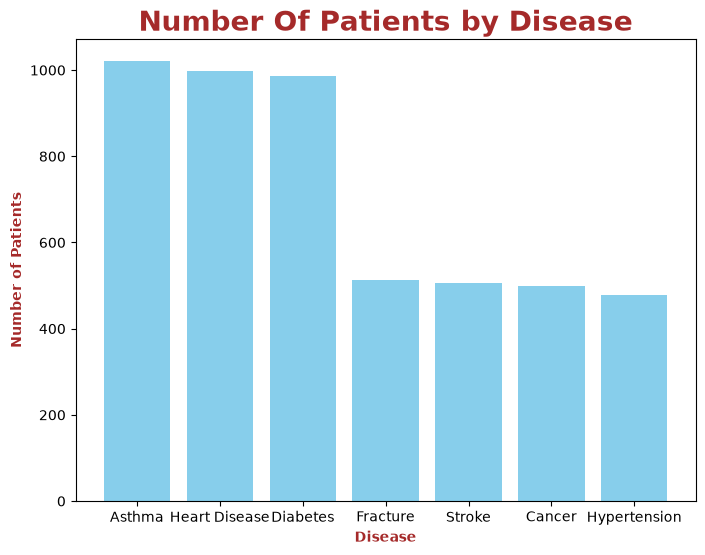

In [75]:
Disease_patient = tdf.groupby("Disease")["Patient_ID"].count().sort_values(ascending = False)
plt.figure(figsize =(8,6))

plt.bar(Disease_patient.index,Disease_patient.values, color = 'skyblue')
plt.title("Number Of Patients by Disease", fontsize = 20, fontweight = "bold", color = "brown")
plt.xlabel("Disease" , fontweight = "bold", color = "brown")
plt.ylabel("Number of Patients", fontweight = "bold", color = "brown")
plt.show()

#### This visualization compares the number of patients diagnosed with each disease. It helps identify the most common medical conditions treated by the hospital. The analysis supports resource planning, medicine inventory management, and department workload allocation. Higher patient counts indicate diseases that require greater operational attention.

Text(0, 0.5, 'Patient Count')

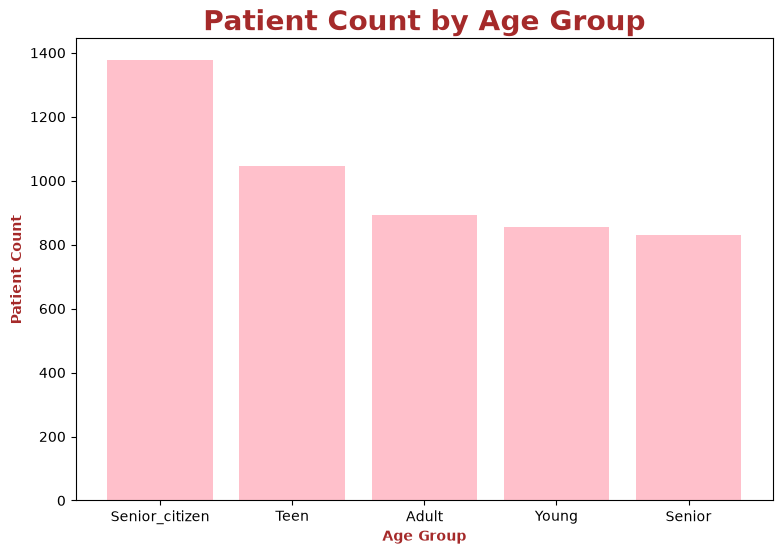

In [76]:
ATC = pd.merge(pdf,adf, on = "Patient_ID")
Age_treament_cost = ATC.groupby("Age_Group")["Patient_ID"].count().sort_values(ascending = False)

plt.figure(figsize = (9,6))
plt.bar(Age_treament_cost.index,Age_treament_cost.values, color = "pink")
plt.title("Patient Count by Age Group", fontsize = 20, fontweight = "bold", color = "brown")
plt.xlabel("Age Group",fontweight = "bold", color = "brown")
plt.ylabel("Patient Count",fontweight = "bold", color = "brown")

#### This chart shows the distribution of patients across different age groups. It helps identify which age category visits the hospital most frequently. Understanding age-wise patient volume supports healthcare planning, targeted treatment strategies, and age-specific service improvements. It also assists management in allocating medical resources efficiently.

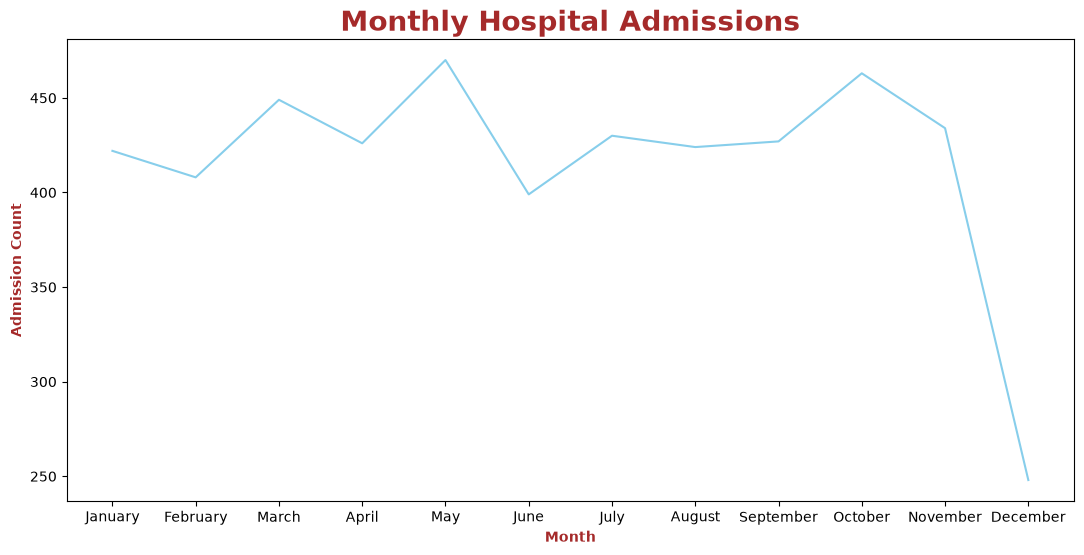

In [77]:
adf["Admission_Month"] = adf["Admission_Date"].dt.month
Month_Admission = adf.groupby("Admission_Month")["Admission_ID"].count()
Month_Admission.index = pd.to_datetime(Month_Admission.index,format = "%m").month_name()

plt.figure(figsize = (13,6))
plt.plot(Month_Admission.index, Month_Admission.values, color = "skyblue")
plt.title("Monthly Hospital Admissions", color = "brown", fontweight = "bold", fontsize = 20)
plt.xlabel("Month", fontweight = "bold", color = "brown")
plt.ylabel("Admission Count", fontweight = "bold", color = "brown")
plt.show()

#### This line chart displays the total number of patient admissions for each month. It is useful for identifying seasonal trends and fluctuations in hospital demand. The analysis helps management forecast future patient load and prepare staff, beds, and medical resources accordingly. Peaks in admissions may indicate periods requiring additional operational planning.

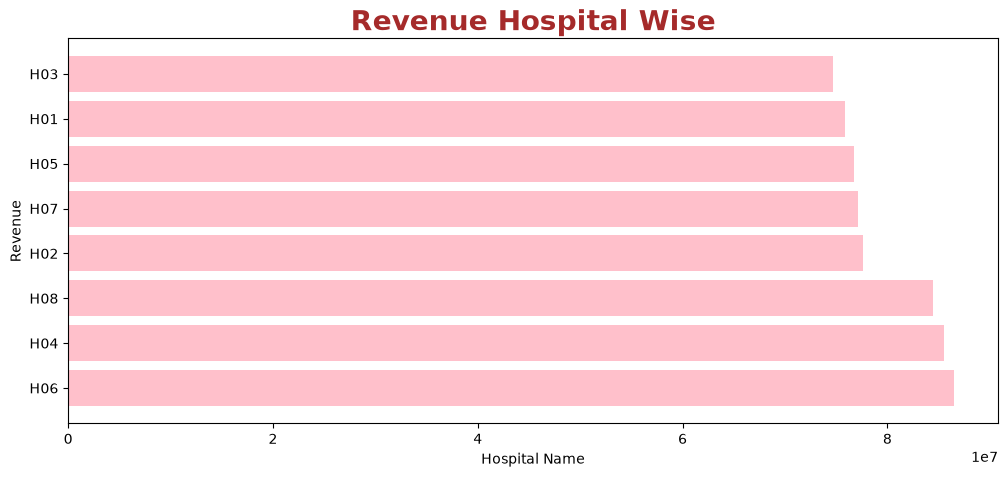

In [78]:
hospital_revenue = adf.groupby("Hospital_ID")["Bill"].sum().sort_values(ascending = False)
plt.figure(figsize = (12,5))

plt.barh(hospital_revenue.index,hospital_revenue.values, color = "pink")
plt.title("Revenue Hospital Wise", fontsize = 20, color = "brown", fontweight = "bold")
plt.xlabel("Hospital Name")
plt.ylabel("Revenue")
plt.show()

#### This visualization compares the total revenue generated by each hospital. It helps identify the highest and lowest revenue-generating hospitals within the dataset. The analysis supports financial performance evaluation and assists management in making strategic investment and operational decisions. Revenue differences may indicate variations in patient volume or treatment costs.

Text(0.5, 1.0, 'Gender Distributio of Patients')

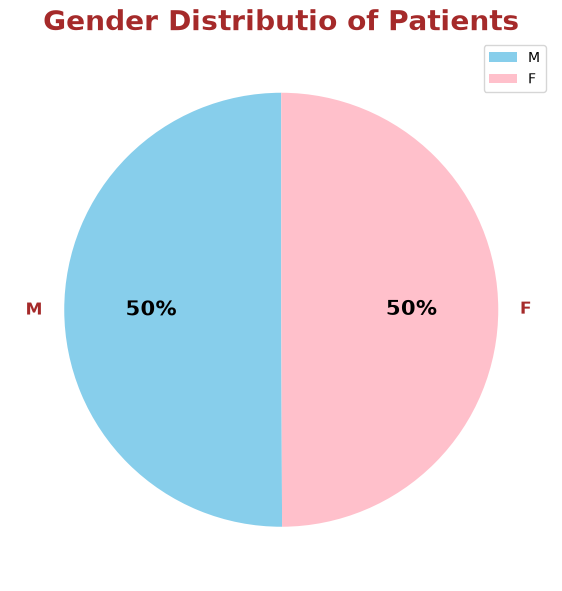

In [79]:
Gender_count = pdf.groupby("Gender")["Patient_ID"].count().sort_values(ascending = False)
plt.figure(figsize = (7,19))

w,t,p = plt.pie(Gender_count.values,
labels = Gender_count.index,
autopct = "%1.0f%%",
startangle = 90,
colors = ["skyblue","pink"])
plt.setp(t, fontsize=12, color="brown", fontweight="bold")
plt.setp(p, fontweight = "bold", fontsize = 15)
plt.legend()
plt.title("Gender Distributio of Patients", fontweight = "bold", fontsize = 20, color = "brown")

#### This pie chart illustrates the proportion of male and female patients in the hospital. It provides a quick overview of the overall patient demographics. The analysis helps understand gender-based healthcare demand and supports planning for gender-specific healthcare services. A balanced distribution indicates equal utilization across genders.

Text(0, 0.5, 'Fequency')

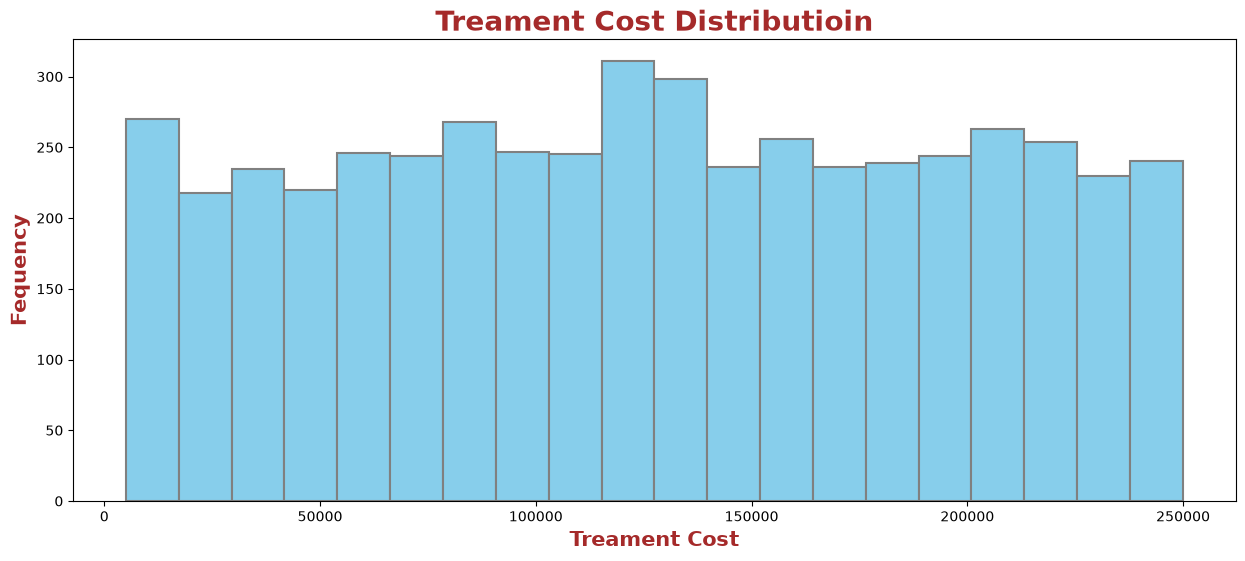

In [80]:
plt.figure(figsize =(15,6))

plt.hist(adf["Bill"],
         bins =20,
         color = "skyblue",
         edgecolor = "grey",
         linewidth = 1.5)
plt.title("Treament Cost Distributioin",fontsize = 20, color = "brown", fontweight = "bold")
plt.xlabel("Treament Cost", fontweight = "bold", color = "brown", fontsize = 15)
plt.ylabel("Fequency",fontweight = "bold", color = "brown", fontsize = 15)

#### This histogram shows how treatment costs are distributed among patients. It helps identify the most common billing range as well as unusually high or low treatment costs. The analysis provides insights into hospital pricing patterns and cost variability. It also helps detect outliers that may require further financial investigation.

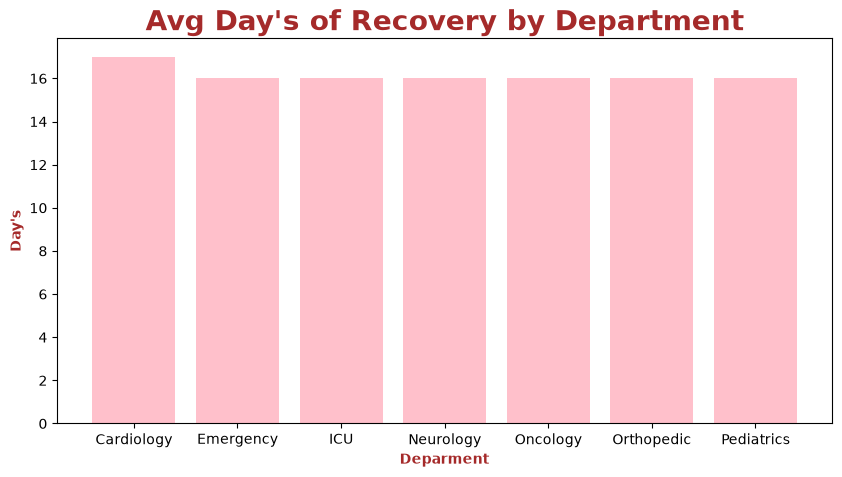

In [81]:
average_stay = pd.merge(tdf, adf, on = "Patient_ID")
astay = average_stay.groupby("Department")["Recovery_Days"].mean().round()
plt.figure(figsize =(10,5))

plt.bar(astay.index,astay.values, color = 'pink')
plt.title("Avg Day's of Recovery by Department", fontsize = 20, fontweight = "bold", color = "brown")
plt.xlabel("Deparment" , fontweight = "bold", color = "brown")
plt.ylabel("Day's", fontweight = "bold", color = "brown")
plt.show()

#### This chart compares the average recovery time across hospital departments. It helps evaluate treatment efficiency and patient recovery performance. Departments with longer recovery periods may require additional analysis to improve patient care. The insights support operational improvements and healthcare quality assessment.

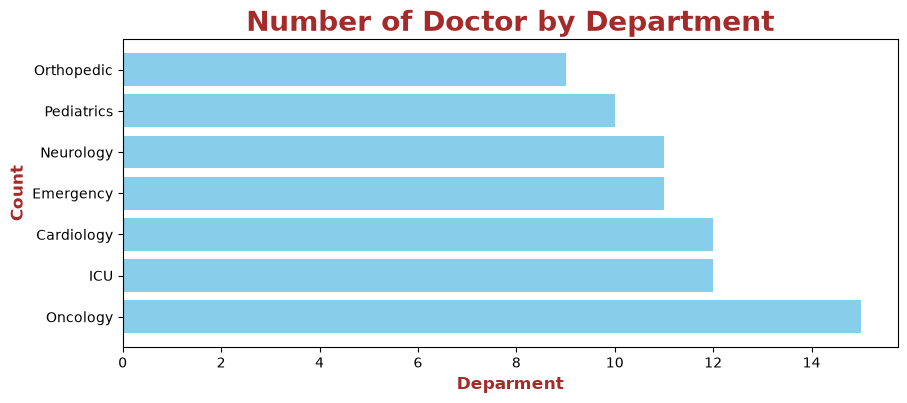

In [82]:
dep_wise_doc = ddf.groupby("Department")["Doctor_ID"].count().sort_values(ascending = False)
plt.figure(figsize = (10,4))

plt.barh(dep_wise_doc.index, dep_wise_doc.values, color = "skyblue")
plt.title("Number of Doctor by Department", fontsize = 20, fontweight = "bold", color = "brown")
plt.xlabel("Deparment" , fontweight = "bold", color = "brown", fontsize = 12)
plt.ylabel("Count", fontweight = "bold", color = "brown", fontsize = 12)
plt.show()

#### This visualization displays the number of doctors available in each department. It helps evaluate staffing distribution across hospital departments. The analysis identifies departments with higher or lower medical workforce availability. These insights support workforce planning and efficient allocation of healthcare professionals.

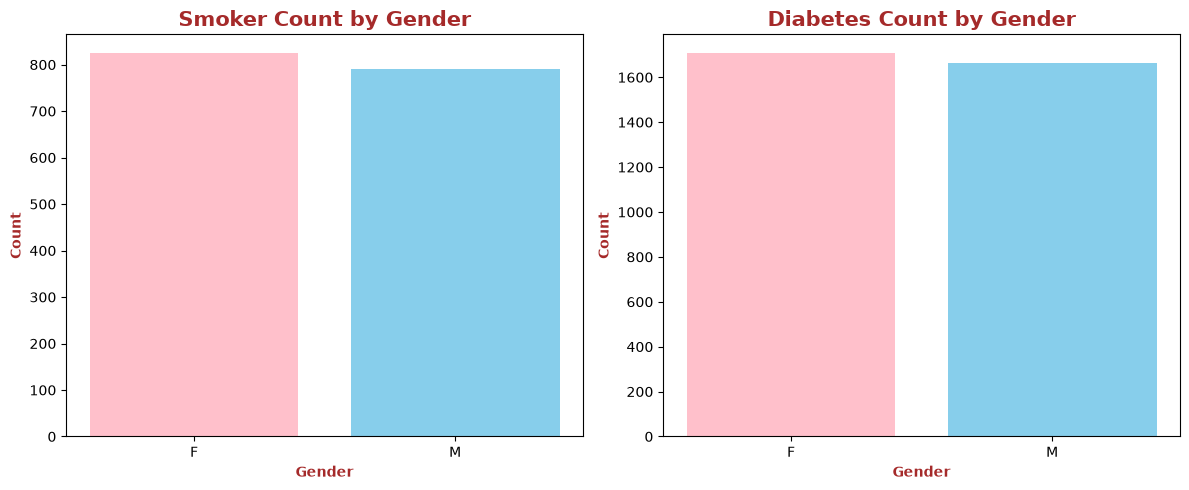

In [83]:
smok = pdf[pdf["Smoking"] == "Yes"]
sk = smok.groupby("Gender")["Patient_ID"].count().sort_values(ascending = False)
Diab = pdf[pdf["Diabetes"] == "Yes"]
Db = Diab.groupby("Gender")["Patient_ID"].count().sort_values(ascending = False)
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
plt.bar(sk.index,sk.values, color = ["pink","skyblue"])
plt.title("Smoker Count by Gender", fontsize = 15, fontweight = "bold", color = "brown")
plt.xlabel("Gender",fontweight = "bold", color = "brown")
plt.ylabel("Count",fontweight = "bold", color = "brown")

plt.subplot(1,2,2)
plt.bar(Db.index,Db.values, color = ["pink","skyblue"])
plt.title("Diabetes Count by Gender", fontsize = 15, fontweight = "bold", color = "brown")
plt.xlabel("Gender", fontweight = "bold", color = "brown")
plt.ylabel("Count", fontweight = "bold", color = "brown")

plt.tight_layout()
plt.show()

#### These charts compare the number of smokers and diabetic patients across genders. They help identify gender-based health patterns related to lifestyle and chronic diseases. The analysis supports preventive healthcare planning and targeted awareness programs. Understanding these trends enables hospitals to design more effective health interventions.

Text(0, 0.5, 'BMI')

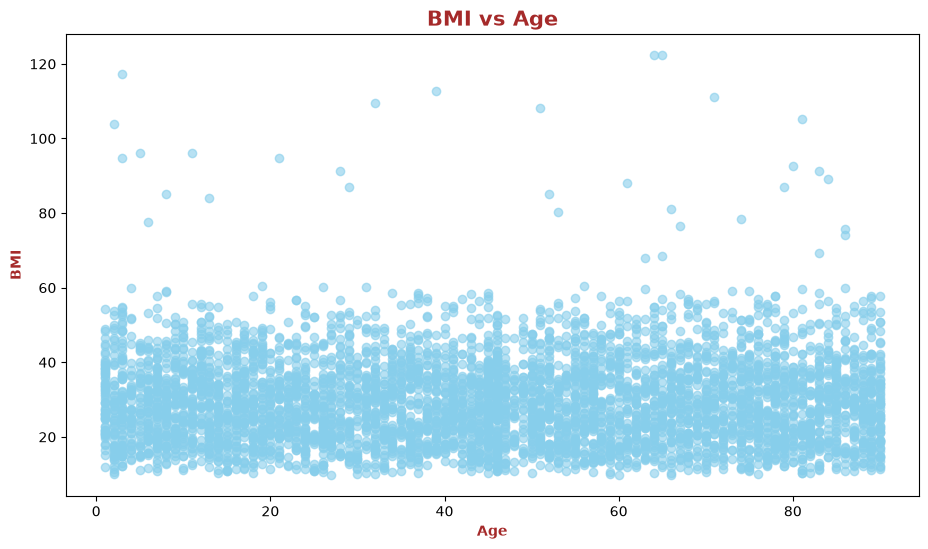

In [84]:
Bmi_age = pd.merge(adf,pdf,on = "Patient_ID")
plt.figure(figsize = (11,6))
plt.scatter(Bmi_age["Age"],Bmi_age["BMI"],alpha = 0.6, color = "skyblue")
plt.title("BMI vs Age", fontsize = 15, fontweight = "bold", color = "brown")
plt.xlabel("Age", fontweight = "bold", color = "brown")
plt.ylabel("BMI", fontweight = "bold", color = "brown")

#### This scatter plot illustrates the relationship between patients' Age and Body Mass Index (BMI). It helps identify whether BMI varies with age and highlights any unusual BMI values or outliers. The visualization also provides an overview of the distribution of BMI across different age groups. Understanding this relationship can support healthcare professionals in identifying age-related health patterns and potential risk factors.

## Insights 
•	The hospital network served 5,000 patients across 8 hospitals, supported by a team of 80 doctors and 4,437 beds, indicating a large healthcare infrastructure.

•	The hospitals generated a total revenue of ₹63.8 Crore, demonstrating strong financial performance across all facilities.

•	On average, each patient incurred a medical bill of ₹1.3 Lakh, reflecting the overall treatment cost per admission.

•	The average patient age was 45 years, suggesting that most patients belonged to the middle-aged population.

•	Patients required an average of 16 recovery days, indicating a moderate average treatment and recovery duration.

•	Doctors had an average of 20 years of experience, highlighting a highly experienced medical workforce.

•	The hospitals maintained an average rating of 4.2 out of 5, indicating a high level of patient satisfaction.

•	The average daily revenue generated per patient was approximately ₹13,248, reflecting efficient revenue generation during hospitalization.

•	The average patient BMI was 29.7, which falls in the overweight category and indicates an increased health risk among the patient population.

•	67.4% of patients had diabetes, showing that diabetes was highly prevalent and represented a major health concern.

•	32.3% of patients were smokers, suggesting that nearly one-third of the patients had a lifestyle risk factor associated with various diseases.

•	Only 21.3% of patients had a healthy BMI, indicating that the majority of patients were either underweight or overweight/obese.

•	Hospital H06 generated the highest billing, contributing ₹86.49 Lakh, making it the top revenue-generating hospital in the network.

•	The ICU department generated the highest revenue of ₹98.29 Lakh, highlighting the significant financial contribution of critical care services.
